In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 300)
sns.set_style('white')

In [3]:
# Importing data from project's Google Drive folder
# orders_cl.csv
url = "https://drive.google.com/file/d/1QxRyjzQsCvtXUm4wsJmQSm5xqBambV_s/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_cl = pd.read_csv(path)
orders_cl['created_date'] = pd.to_datetime(orders_cl['created_date'])

# orderlines_cl.csv
url = "https://drive.google.com/file/d/1aMDQQRPAxZWFWWrqnsV8FZKy6-HYVvt8/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_cl = pd.read_csv(path)
orderlines_cl['date'] = pd.to_datetime(orderlines_cl['date'])

# orderlines_expanded.csv
url = "https://drive.google.com/file/d/1qQz3SXZhSMAij9ap0aDloGGm_AGiVId7/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_expanded = pd.read_csv(path)
orderlines_expanded['date'] = pd.to_datetime(orderlines_cl['date'])

#products_cl.csv
url = "https://drive.google.com/file/d/1kBppFVgzFdbFIWfT2Jer-85png9Xwp5r/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cl = pd.read_csv(path)

In [4]:
# merging orders_cl with order revenue info from orderlines_cl
order_revenue = orderlines_expanded.groupby('id_order')['unit_price_total'].sum()
orders_cl = orders_cl.merge(order_revenue, right_index = True, left_on = 'order_id').copy()

In [5]:
# checking differences between total_paid and unit_price_total for each order to check for possible discounts at order level
orders_cl['payment_diff'] = orders_cl['total_paid'] - orders_cl['unit_price_total']
orders_discount = orders_cl.loc[orders_cl['payment_diff'] < 0].copy()

In [6]:
# checking the absolute values of those discounts
orders_discount['abs_payment_diff'] = orders_discount['payment_diff'].abs()
discounts_effect_per_order = orders_discount['abs_payment_diff'].sum() / orders_discount['abs_payment_diff'].count()
discounts_effect_per_order

np.float64(0.9110558252427414)

In [10]:
orderlines_expanded

,id,id_order,product_id,product_quantity,sku,unit_price,date,name,desc,price,in_stock,type,category,brand,revenue,discount,total_discount,percentage_discount,unit_price_total
0,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16,OWC In-line Digital Temperature Sensor Kit HDD iMac 2011,Kit temperature sensor for HDD iMac 21 inch and 27 inch 2011.,60.99,1.00,12755395,Others,OWC,47.49,13.50,13.50,22.13,47.49
1,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s / 5c / 4S,22.95,0.00,5720,"Audio, Peripherals & Accessories",iOttie,18.99,3.96,3.96,17.25,18.99
2,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11,"Apple 85W MagSafe 2 charger MacBook Pro screen Retina 15 ""(OEM)",Apple MagSafe 2 Charger for MacBook Pro 15-inch Retina 85W unboxed,89.00,1.00,13005399,"Audio, Peripherals & Accessories",Apple,72.19,16.81,16.81,18.89,72.19
3,1119126,299549,0,1,PAC0929,2565.99,2017-01-01 02:07:42,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB | 2TB Drive Fusion",IMac desktop computer 27 inch Retina 5K RAM 32GB 2TB Drive Fusion (MK462Y / A).,3209.00,0.00,1282,Apple Computers & Desktops,Pack,2565.99,643.01,643.01,20.04,2565.99
4,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with 555MB for Mac and PC.,76.99,0.00,1298,Open Items / Resale,Crucial,60.90,16.09,16.09,20.90,60.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58186,1649447,527035,0,1,APP0698,9.99,2018-03-14 11:36:24,Apple Lightning Cable Connector to USB 1m White (OEM),Apple Lightning USB Cable 1 meter to charge and sync iPhone iPad and iPod,25.00,1.00,1230,"Cables, Adapters & Networking",Apple,9.99,15.01,15.01,60.04,9.99
58187,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:37:27,Apple Lightning Cable Connector to USB 1m White (OEM),Apple Lightning USB Cable 1 meter to charge and sync iPhone iPad and iPod,25.00,1.00,1230,"Cables, Adapters & Networking",Apple,19.98,15.01,30.02,60.04,19.98
58188,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:38:31,Apple Lightning Cable Connector to USB 1m White (OEM),Apple Lightning USB Cable 1 meter to charge and sync iPhone iPad and iPod,25.00,1.00,1230,"Cables, Adapters & Networking",Apple,19.98,15.01,30.02,60.04,19.98
58189,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:40:54,Apple Lightning Cable Connector to USB 1m White (OEM),Apple Lightning USB Cable 1 meter to charge and sync iPhone iPad and iPod,25.00,1.00,1230,"Cables, Adapters & Networking",Apple,29.97,15.01,45.03,60.04,29.97


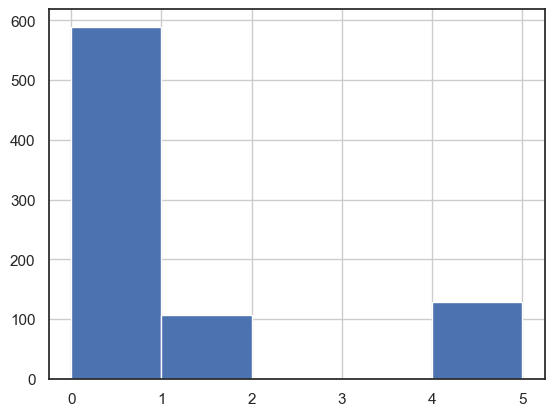

In [ ]:
orders_discount['abs_payment_diff'].hist(bins = 5);

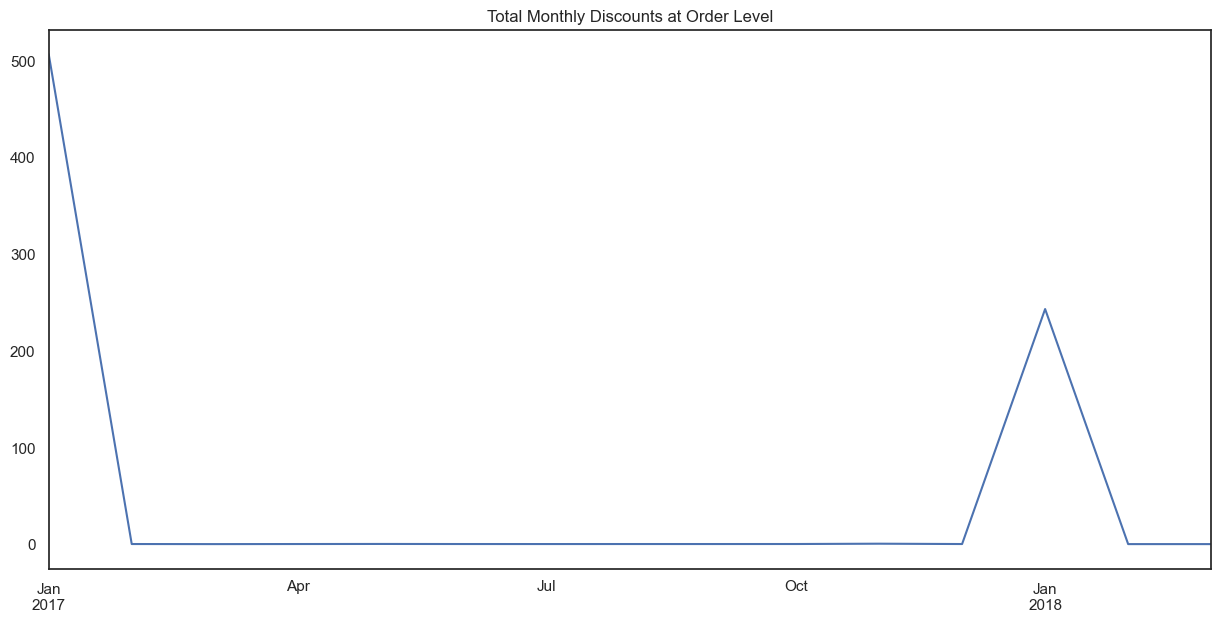

In [ ]:
monthly_abs_discounts = orders_discount.resample('ME', on = 'created_date')['abs_payment_diff'].sum()
monthly_abs_discounts.plot(title = 'Total Monthly Discounts at Order Level', xlabel = '', figsize = (15,7));

In [ ]:
# checking for relative values of discounts
orders_discount['rel_payment_diff'] = orders_discount['abs_payment_diff'] * 100 / orders_discount['unit_price_total']

In [ ]:
orders_discount_above_3 = orders_discount.loc[orders_discount['rel_payment_diff'] >= 3].copy()
orders_discount_above_3['rel_payment_diff'].describe()

count   65.00
mean     7.49
std      2.02
min      3.10
25%      5.75
50%      8.33
75%      9.26
max      9.89
Name: rel_payment_diff, dtype: float64

In [ ]:
orders_discount_above_5 = orders_discount.loc[orders_discount['rel_payment_diff'] >= 5].copy()
orders_discount_above_5['rel_payment_diff'].describe()

count   55.00
mean     8.14
std      1.41
min      5.00
25%      7.42
50%      8.42
75%      9.26
max      9.89
Name: rel_payment_diff, dtype: float64

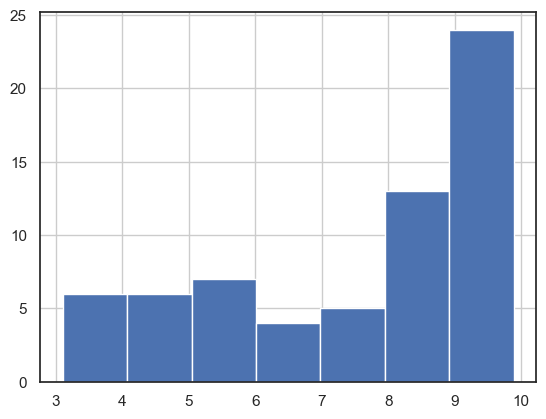

In [ ]:
orders_discount_above_3['rel_payment_diff'].hist(bins = 7);

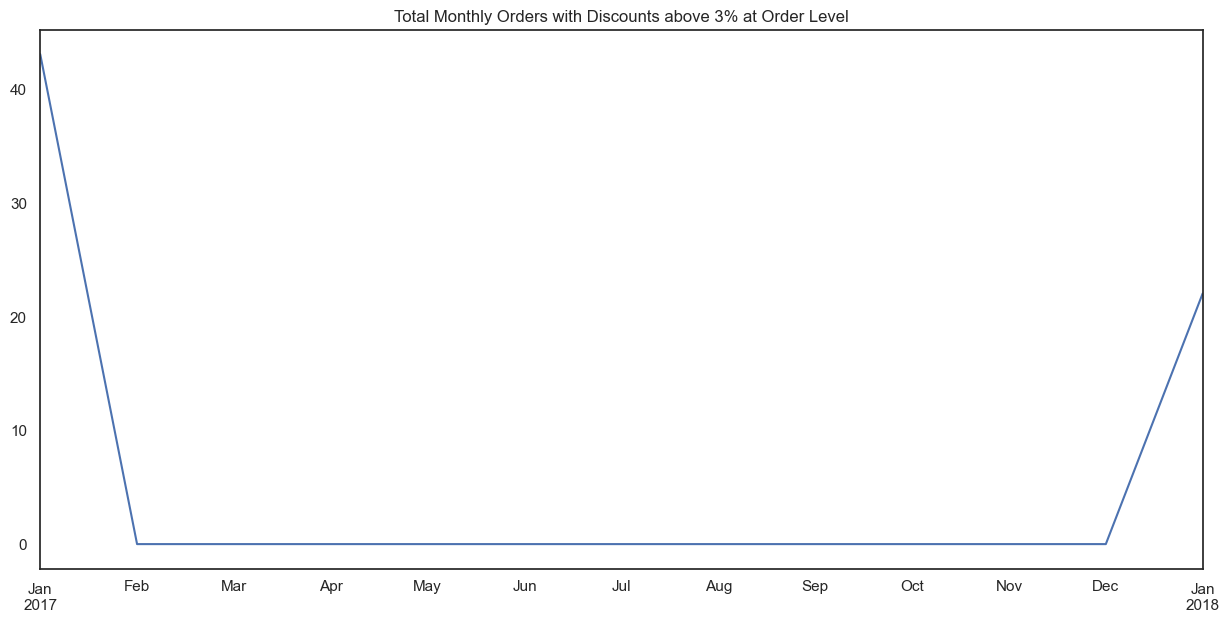

In [ ]:
monthly_rel_discounts = orders_discount_above_3.resample('ME', on = 'created_date')['rel_payment_diff'].count()
monthly_rel_discounts.plot(title = 'Total Monthly Orders with Discounts above 3% at Order Level', xlabel = '', figsize = (15,7));

In [ ]:
avg_order_price_week = orders_cl.resample('W', on = 'created_date')['total_paid'].mean().reset_index()

#Average order price over time

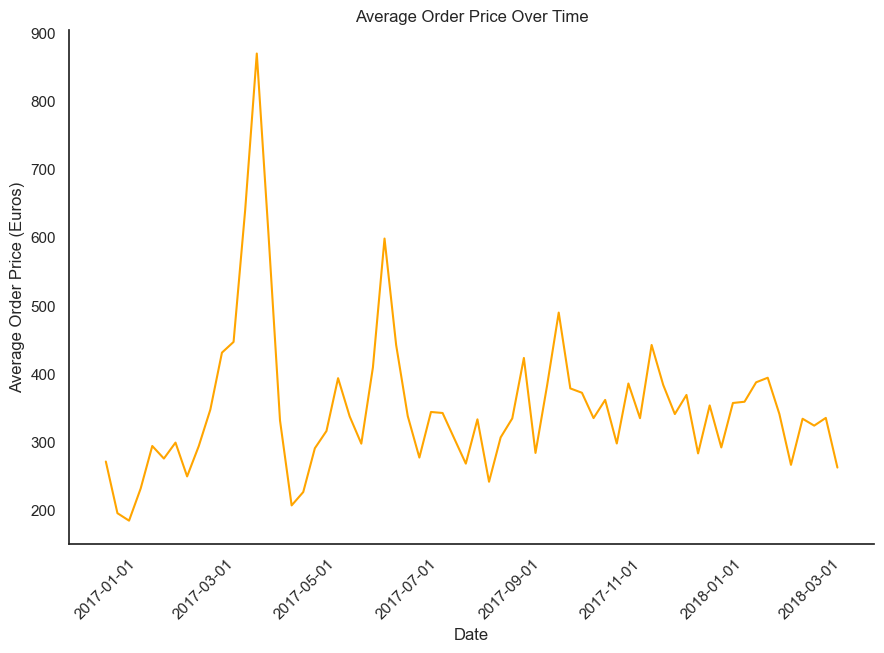

In [ ]:
avg_ord_price_time = sns.relplot(data=avg_order_price_week, x = 'created_date', y = 'total_paid', kind='line',color='orange',
            height=6, aspect=1.5)
avg_ord_price_time.set(title="Average Order Price Over Time", xlabel="Date", ylabel="Average Order Price (Euros)")
avg_ord_price_time.set_xticklabels(rotation=45)
plt.savefig("Avg_weekly_order_price.png", dpi=300, bbox_inches="tight");

# Analyzing discounts at product level

In [ ]:
orderlines_expanded['discounted'] = orderlines_expanded['price'] > orderlines_expanded['unit_price']
orderlines_expanded['percentage_discount_total'] = orderlines_expanded['percentage_discount'] * orderlines_expanded['product_quantity']

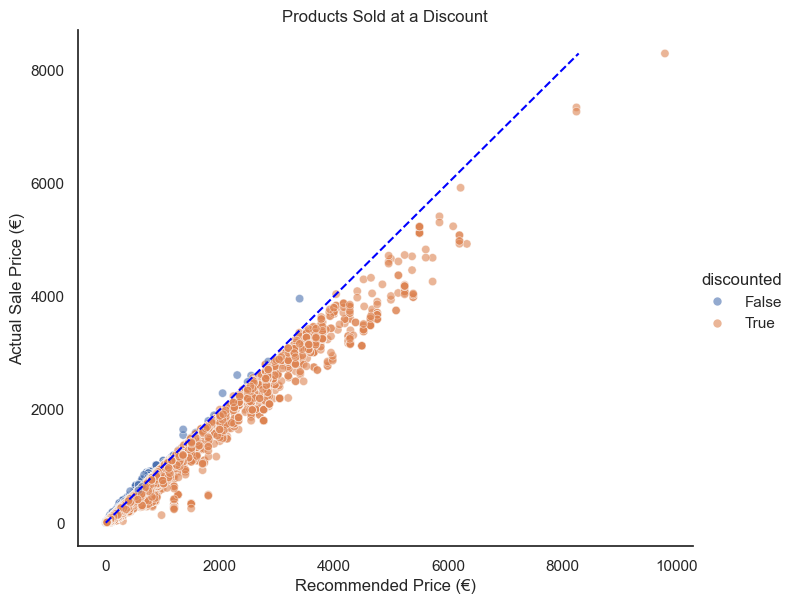

In [ ]:
g = sns.relplot(
    data=orderlines_expanded,
    x="price",
    y="unit_price",
    kind="scatter",
    alpha=0.6,
    height=6,
    aspect=1.2,
    hue="discounted"
)

# Add diagonal line (price = unit_price)
ax = g.ax
lims = [
    max(orderlines_expanded["price"].min(), orderlines_expanded["unit_price"].min()),
    min(orderlines_expanded["price"].max(), orderlines_expanded["unit_price"].max())
]
ax.plot(lims, lims, '--', color='blue')
ax.set_title("Products Sold at a Discount")
ax.set_xlabel("Recommended Price (€)")
ax.set_ylabel("Actual Sale Price (€)")
plt.savefig("Price_recommended_x_price_sold.png", dpi=300, bbox_inches="tight");

In [ ]:
discounted = orderlines_expanded.loc[orderlines_expanded['discounted'] == True].reset_index(drop = True).copy()

In [ ]:
avg_discount = discounted['percentage_discount_total'].sum() / discounted['product_quantity'].sum()
avg_discount

np.float64(22.492408803769855)

#Resampling data on weekly basis

In [ ]:
# resampling data on weekly basis
discount_week_agg = discounted.resample('W', on = 'date').agg({'product_quantity': 'sum', 'revenue': 'sum', 'percentage_discount' : 'mean',
                                                               'percentage_discount_total': 'sum'}).reset_index()
discount_week_agg['revenue_per_item'] = discount_week_agg['revenue'] / discount_week_agg['product_quantity']
discount_week_agg['average_discount'] = discount_week_agg['percentage_discount_total'] / discount_week_agg['product_quantity']
discount_week_agg['revenue_millions'] = discount_week_agg['revenue']/1000000

In [ ]:
## week with highest revenue
discount_week_agg.loc[discount_week_agg['revenue'] == discount_week_agg['revenue'].max(),
    ['date', 'product_quantity', 'revenue','revenue_per_item', 'average_discount']]

,date,product_quantity,revenue,revenue_per_item,average_discount
47,2017-11-26,6196,1730330.96,279.27,22.63


In [ ]:
## week with highest average discount
discount_week_agg.loc[discount_week_agg['average_discount'] == discount_week_agg['average_discount'].max(),
    ['date', 'product_quantity', 'revenue','revenue_per_item', 'average_discount']]

,date,product_quantity,revenue,revenue_per_item,average_discount
27,2017-07-09,1197,197790.42,165.24,31.74


In [ ]:
## week with most products sold
discount_week_agg.loc[discount_week_agg['product_quantity'] == discount_week_agg['product_quantity'].max(),
    ['date', 'product_quantity', 'revenue','revenue_per_item', 'average_discount']]

,date,product_quantity,revenue,revenue_per_item,average_discount
47,2017-11-26,6196,1730330.96,279.27,22.63


In [ ]:
## week with lowest revenue
discount_week_agg.loc[discount_week_agg['revenue'] == discount_week_agg['revenue'].min(),
    ['date', 'product_quantity', 'revenue','revenue_per_item', 'average_discount']]

,date,product_quantity,revenue,revenue_per_item,average_discount
10,2017-03-12,52,13136.49,252.62,19.34


In [ ]:
## week with lowest average discount
discount_week_agg.loc[discount_week_agg['average_discount'] == discount_week_agg['average_discount'].min(),
    ['date', 'product_quantity', 'revenue','revenue_per_item', 'average_discount']]

,date,product_quantity,revenue,revenue_per_item,average_discount
50,2017-12-17,1518,395796.98,260.74,16.17


In [ ]:
## week with least products sold
discount_week_agg.loc[discount_week_agg['product_quantity'] == discount_week_agg['product_quantity'].min(),
    ['date', 'product_quantity', 'revenue','revenue_per_item', 'average_discount']]

,date,product_quantity,revenue,revenue_per_item,average_discount
11,2017-03-19,39,15072.85,386.48,19.44


#Total weekly sales overtime

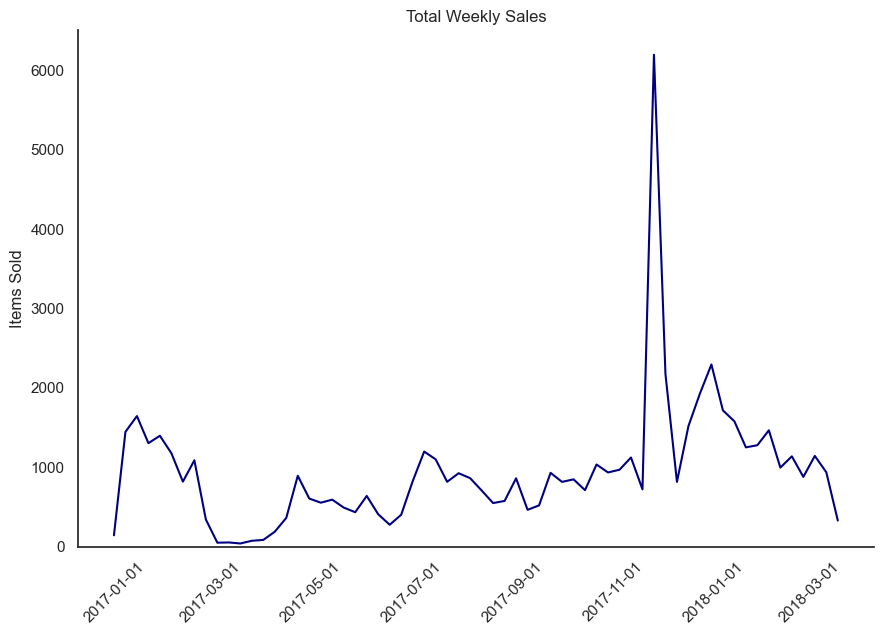

In [ ]:
total_sales_time = sns.relplot(data=discount_week_agg, x = 'date', y = 'product_quantity', kind='line',color='navy',
            height=6, aspect=1.5)
total_sales_time.set(title="Total Weekly Sales", xlabel="", ylabel="Items Sold", ylim = (0, None))
total_sales_time.set_xticklabels(rotation=45)
plt.savefig("Total_weekly_sales.png", dpi=300, bbox_inches="tight");

#Total Weekly Revenue

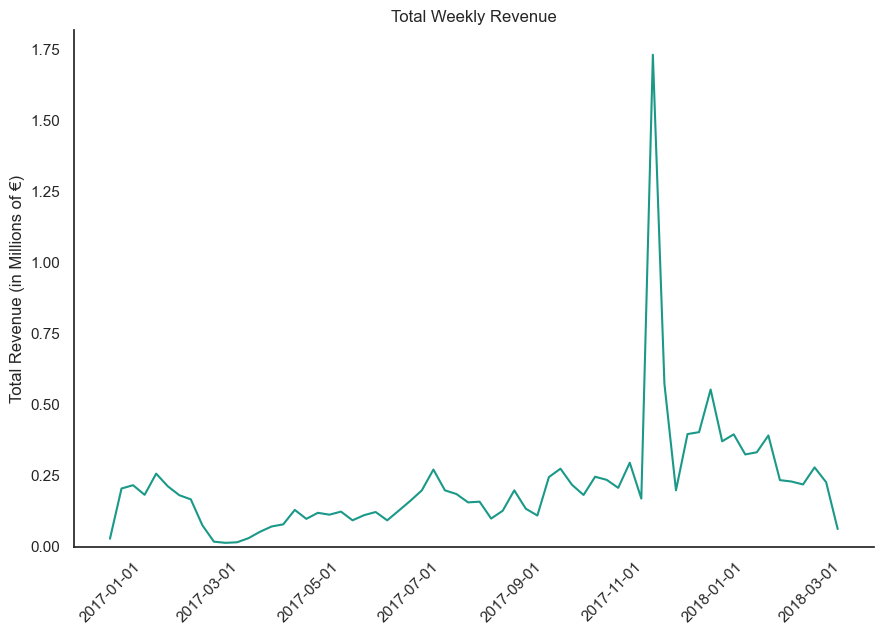

In [ ]:
total_rev_time = sns.relplot(data=discount_week_agg, x = 'date', y = 'revenue_millions', kind='line',color='#1A9988',
            height=6, aspect=1.5)
total_rev_time.set(title="Total Weekly Revenue", xlabel="", ylabel="Total Revenue (in Millions of €)", ylim = (0, None))
total_rev_time.set_xticklabels(rotation=45)
plt.savefig("Weekly_revenue.png", dpi=300, bbox_inches="tight");

#Average Weekly Revenue per Item Sold

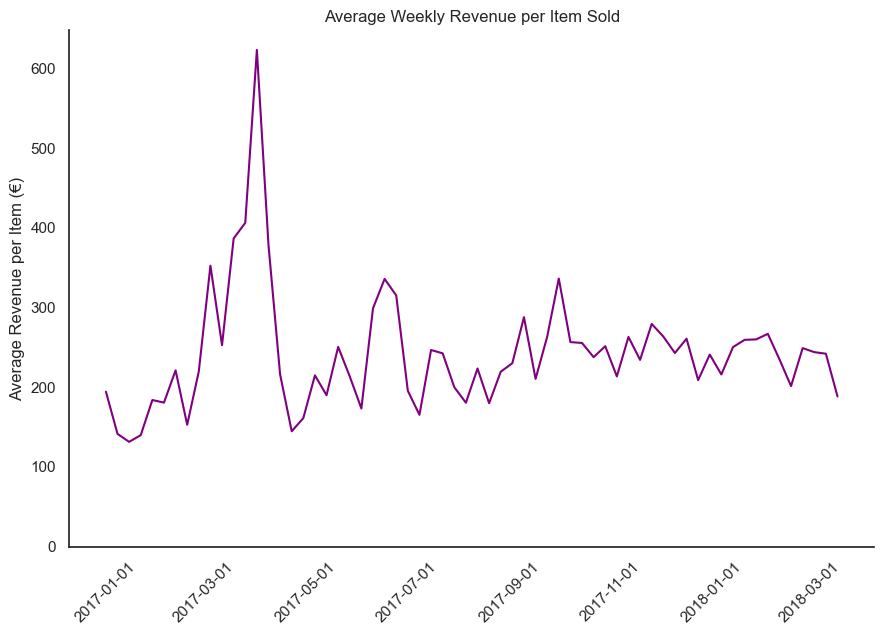

In [ ]:
avg_rev_item_time = sns.relplot(data=discount_week_agg, x = 'date', y = 'revenue_per_item', kind='line',color='purple',
            height=6, aspect=1.5)
avg_rev_item_time.set(title="Average Weekly Revenue per Item Sold", xlabel="", ylabel="Average Revenue per Item (€)", ylim = (0, None))
avg_rev_item_time.set_xticklabels(rotation=45)
plt.savefig("Avg_weekly_rev_item.png", dpi=300, bbox_inches="tight");

#Average Weekly Product Discount

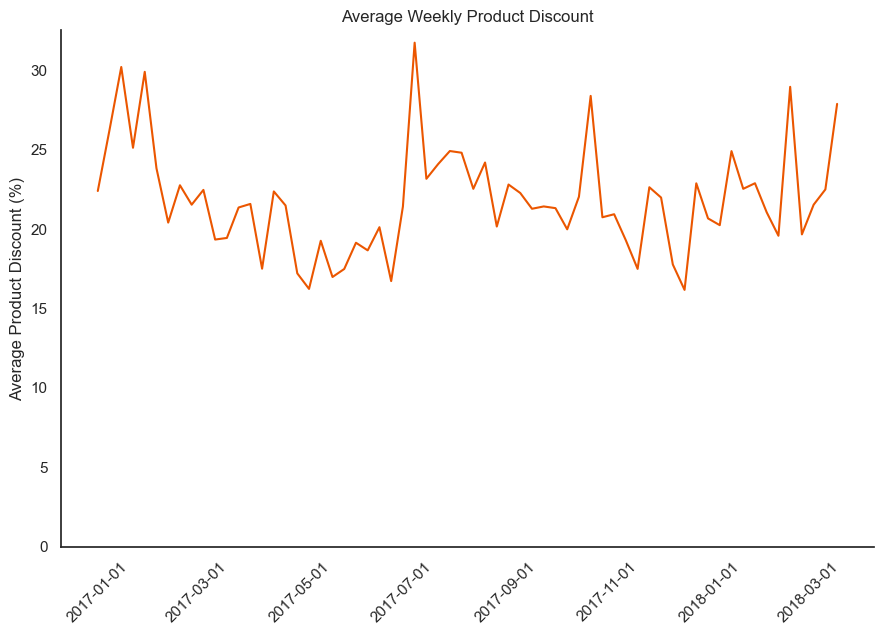

In [ ]:
avg_disc_time = sns.relplot(data=discount_week_agg, x = 'date', y = 'average_discount', kind='line',color='#EB5600',
            height=6, aspect=1.5)
avg_disc_time.set(title="Average Weekly Product Discount", xlabel="", ylabel="Average Product Discount (%)", ylim = (0, None))
avg_disc_time.set_xticklabels(rotation=45)
plt.savefig("Avg_weekly_discount.png", dpi=300, bbox_inches="tight");

#Weekly Revenue and Average Product Discount

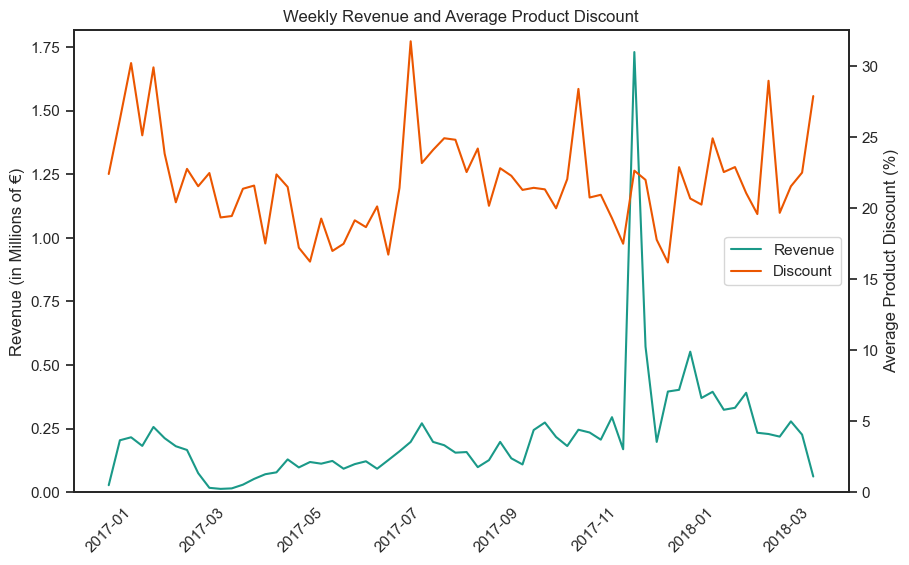

In [ ]:
# plotting reveune and average discounts on the same chart
fig, ax1 = plt.subplots(figsize = (10,6))

sns.lineplot(data = discount_week_agg, x = 'date', y = 'revenue_millions', ax = ax1, color = '#1A9988', label = 'Revenue')
ax1.set_xlabel('')
ax1.set_ylabel('Revenue (in Millions of €)')
ax1.set_ylim(0, None)
ax1.tick_params(axis = 'x', labelrotation = 45)
ax2 = ax1.twinx()

sns.lineplot(data = discount_week_agg, x = 'date', y = 'average_discount', ax = ax2, color = '#EB5600', label = 'Discount')
ax2.set_ylabel('Average Product Discount (%)')
ax2.set_ylim(0, None)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc = 'center right')
if ax2.get_legend():
    ax2.get_legend().remove()
plt.title('Weekly Revenue and Average Product Discount')
plt.savefig("Weekly_revenue_x_avg_discount.png", dpi=300, bbox_inches="tight")
plt.show();

#Weekly Number of Products Sold and Average Product Discount

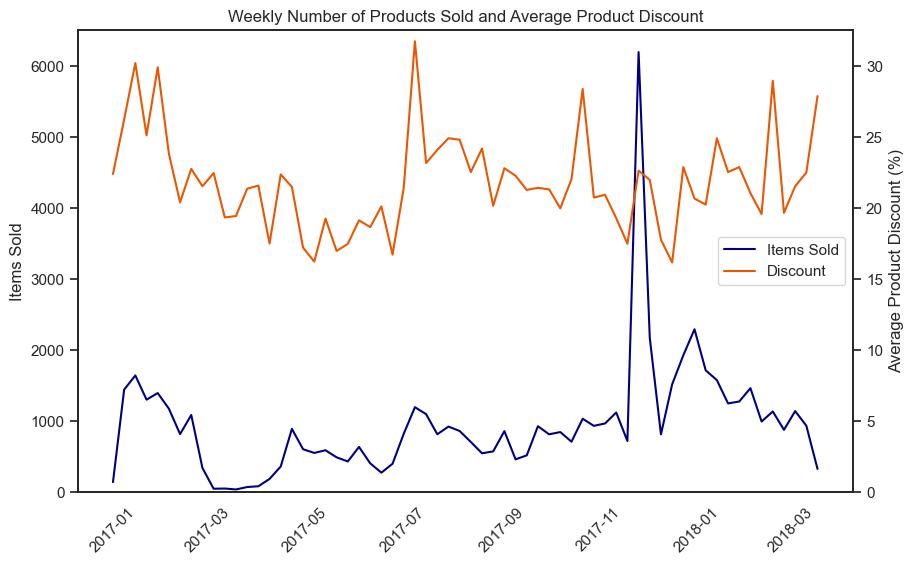

In [ ]:
# plotting items sold and average discounts on the same chart
fig, ax1 = plt.subplots(figsize = (10,6))

sns.lineplot(data = discount_week_agg, x = 'date', y = 'product_quantity', ax = ax1, color = 'navy', label = 'Items Sold')
ax1.set_xlabel('')
ax1.set_ylabel('Items Sold')
ax1.set_ylim(0, None)
ax1.tick_params(axis = 'x', labelrotation = 45)
ax2 = ax1.twinx()

sns.lineplot(data = discount_week_agg, x = 'date', y = 'average_discount', ax = ax2, color = '#EB5600', label = 'Discount')
ax2.set_ylabel('Average Product Discount (%)')
ax2.set_ylim(0, None)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc = 'center right')
if ax2.get_legend():
    ax2.get_legend().remove()
plt.title('Weekly Number of Products Sold and Average Product Discount')
plt.savefig("Weekly_sales_x_avg_discount.png", dpi=300, bbox_inches="tight")
plt.show();

#Weekly Average Revenue per Item Sold and Average Product Discount

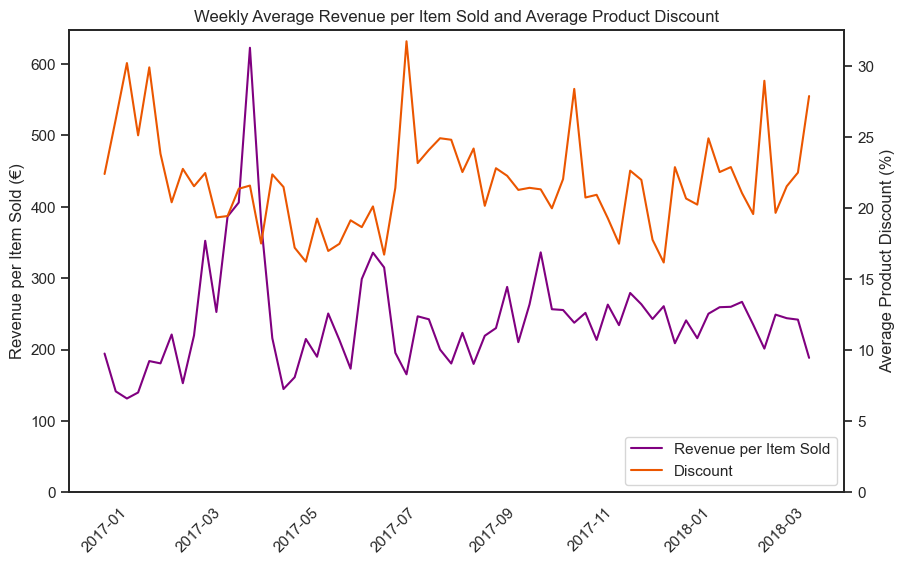

In [ ]:
# plotting average revenue per item sold and average discounts on the same chart
fig, ax1 = plt.subplots(figsize = (10,6))

sns.lineplot(data = discount_week_agg, x = 'date', y = 'revenue_per_item', ax = ax1, color = 'purple', label = 'Revenue per Item Sold')
ax1.set_xlabel('')
ax1.set_ylabel('Revenue per Item Sold (€)')
ax1.set_ylim(0, None)
ax1.tick_params(axis = 'x', labelrotation = 45)
ax2 = ax1.twinx()

sns.lineplot(data = discount_week_agg, x = 'date', y = 'average_discount', ax = ax2, color = '#EB5600', label = 'Discount')
ax2.set_ylabel('Average Product Discount (%)')
ax2.set_ylim(0, None)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc = 'lower right')
if ax2.get_legend():
    ax2.get_legend().remove()
plt.title('Weekly Average Revenue per Item Sold and Average Product Discount')
plt.savefig("Weekly_rev_item_x_avg_discount.png", dpi=300, bbox_inches="tight")
plt.show();

In [ ]:
# resampling data weekly grouped by categories
discount_week_cat_agg = discounted.groupby('category').resample('W', on = 'date').agg({'product_quantity': 'sum', 'revenue': 'sum', 'percentage_discount' : 'mean',
                                                                                       'percentage_discount_total': 'sum'}).reset_index()
discount_week_cat_agg['revenue_per_item'] = discount_week_cat_agg['revenue'] / discount_week_cat_agg['product_quantity']
discount_week_cat_agg['average_discount'] = discount_week_cat_agg['percentage_discount_total'] / discount_week_cat_agg['product_quantity']

# Multi-Facet Visualization - Plotting revenue x average discounts grouped by category

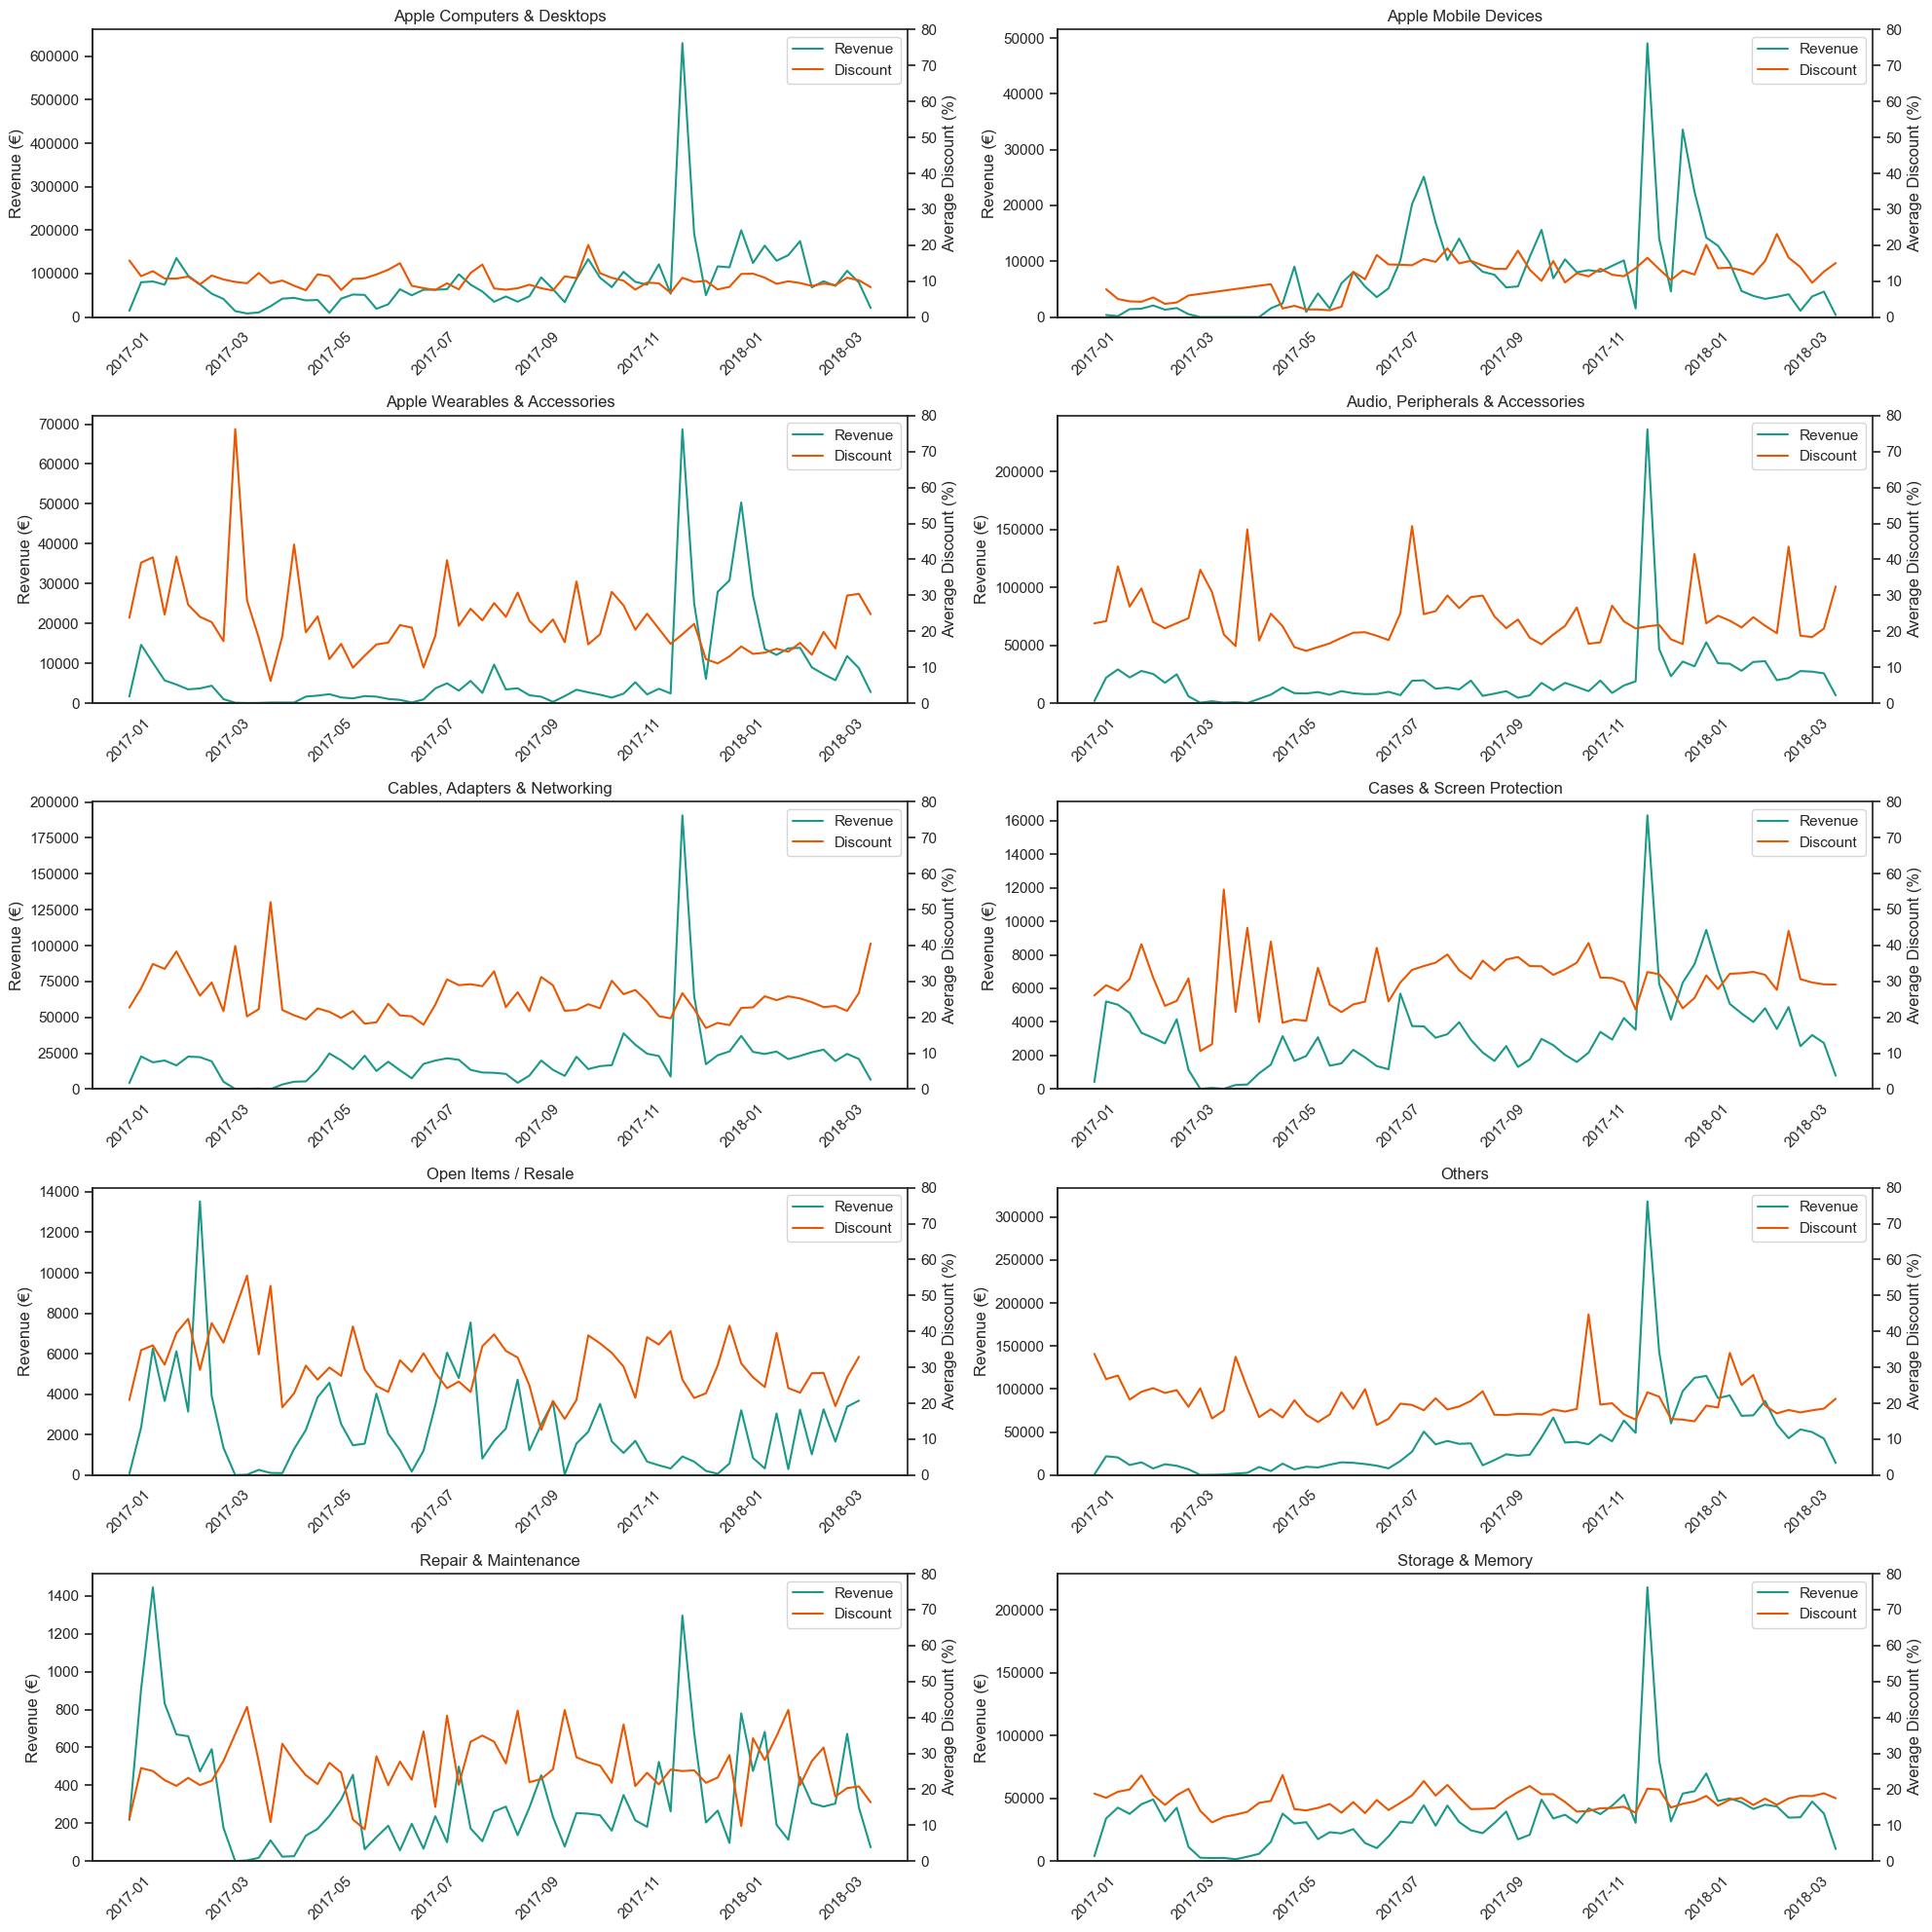

In [ ]:
# Plotting revenue x average discounts grouped by category
# 1. Initialize the FacetGrid (one subplot per category)
g = sns.FacetGrid(discount_week_cat_agg, col='category', col_wrap=2, height=4, aspect = 2.5, sharey=False)

# 2. Define the plotting function for the dual axis
def dual_axis_plot(data, **kwargs):
    ax = plt.gca()  # Get current axis

    # Plot Revenue (Primary Y-axis - Blue)
    sns.lineplot(data=data, x='date', y='revenue', ax=ax, color='#1A9988', label='Revenue')
    ax.set_xlabel("")
    ax.set_ylabel('Revenue (€)')
    ax.set_ylim(0, None)
    ax.tick_params(axis='x', labelrotation = 45)

    # Create the secondary axis
    ax2 = ax.twinx()

    # Plot Average Discount (Secondary Y-axis - Red)
    sns.lineplot(data=data, x='date', y='average_discount', ax=ax2, color='#EB5600', label='Discount')
    ax2.set_ylabel('Average Discount (%)')
    ax2.set_ylim(0, 80)

    # Optional: Combine legends so they don't overlap
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='best')

# 3. Map the function to the grid
g.map_dataframe(dual_axis_plot)

for ax in g.axes.flat:
    ax.tick_params(labelbottom=True)

# 4. Final Formatting
#g.set_axis_labels("Date", "")
g.set_titles("{col_name}")
plt.tight_layout()
plt.savefig("Weekly_revenue_x_avg_discount_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

# Multi-Facet Visualization - Plotting total sales x average discounts grouped by category

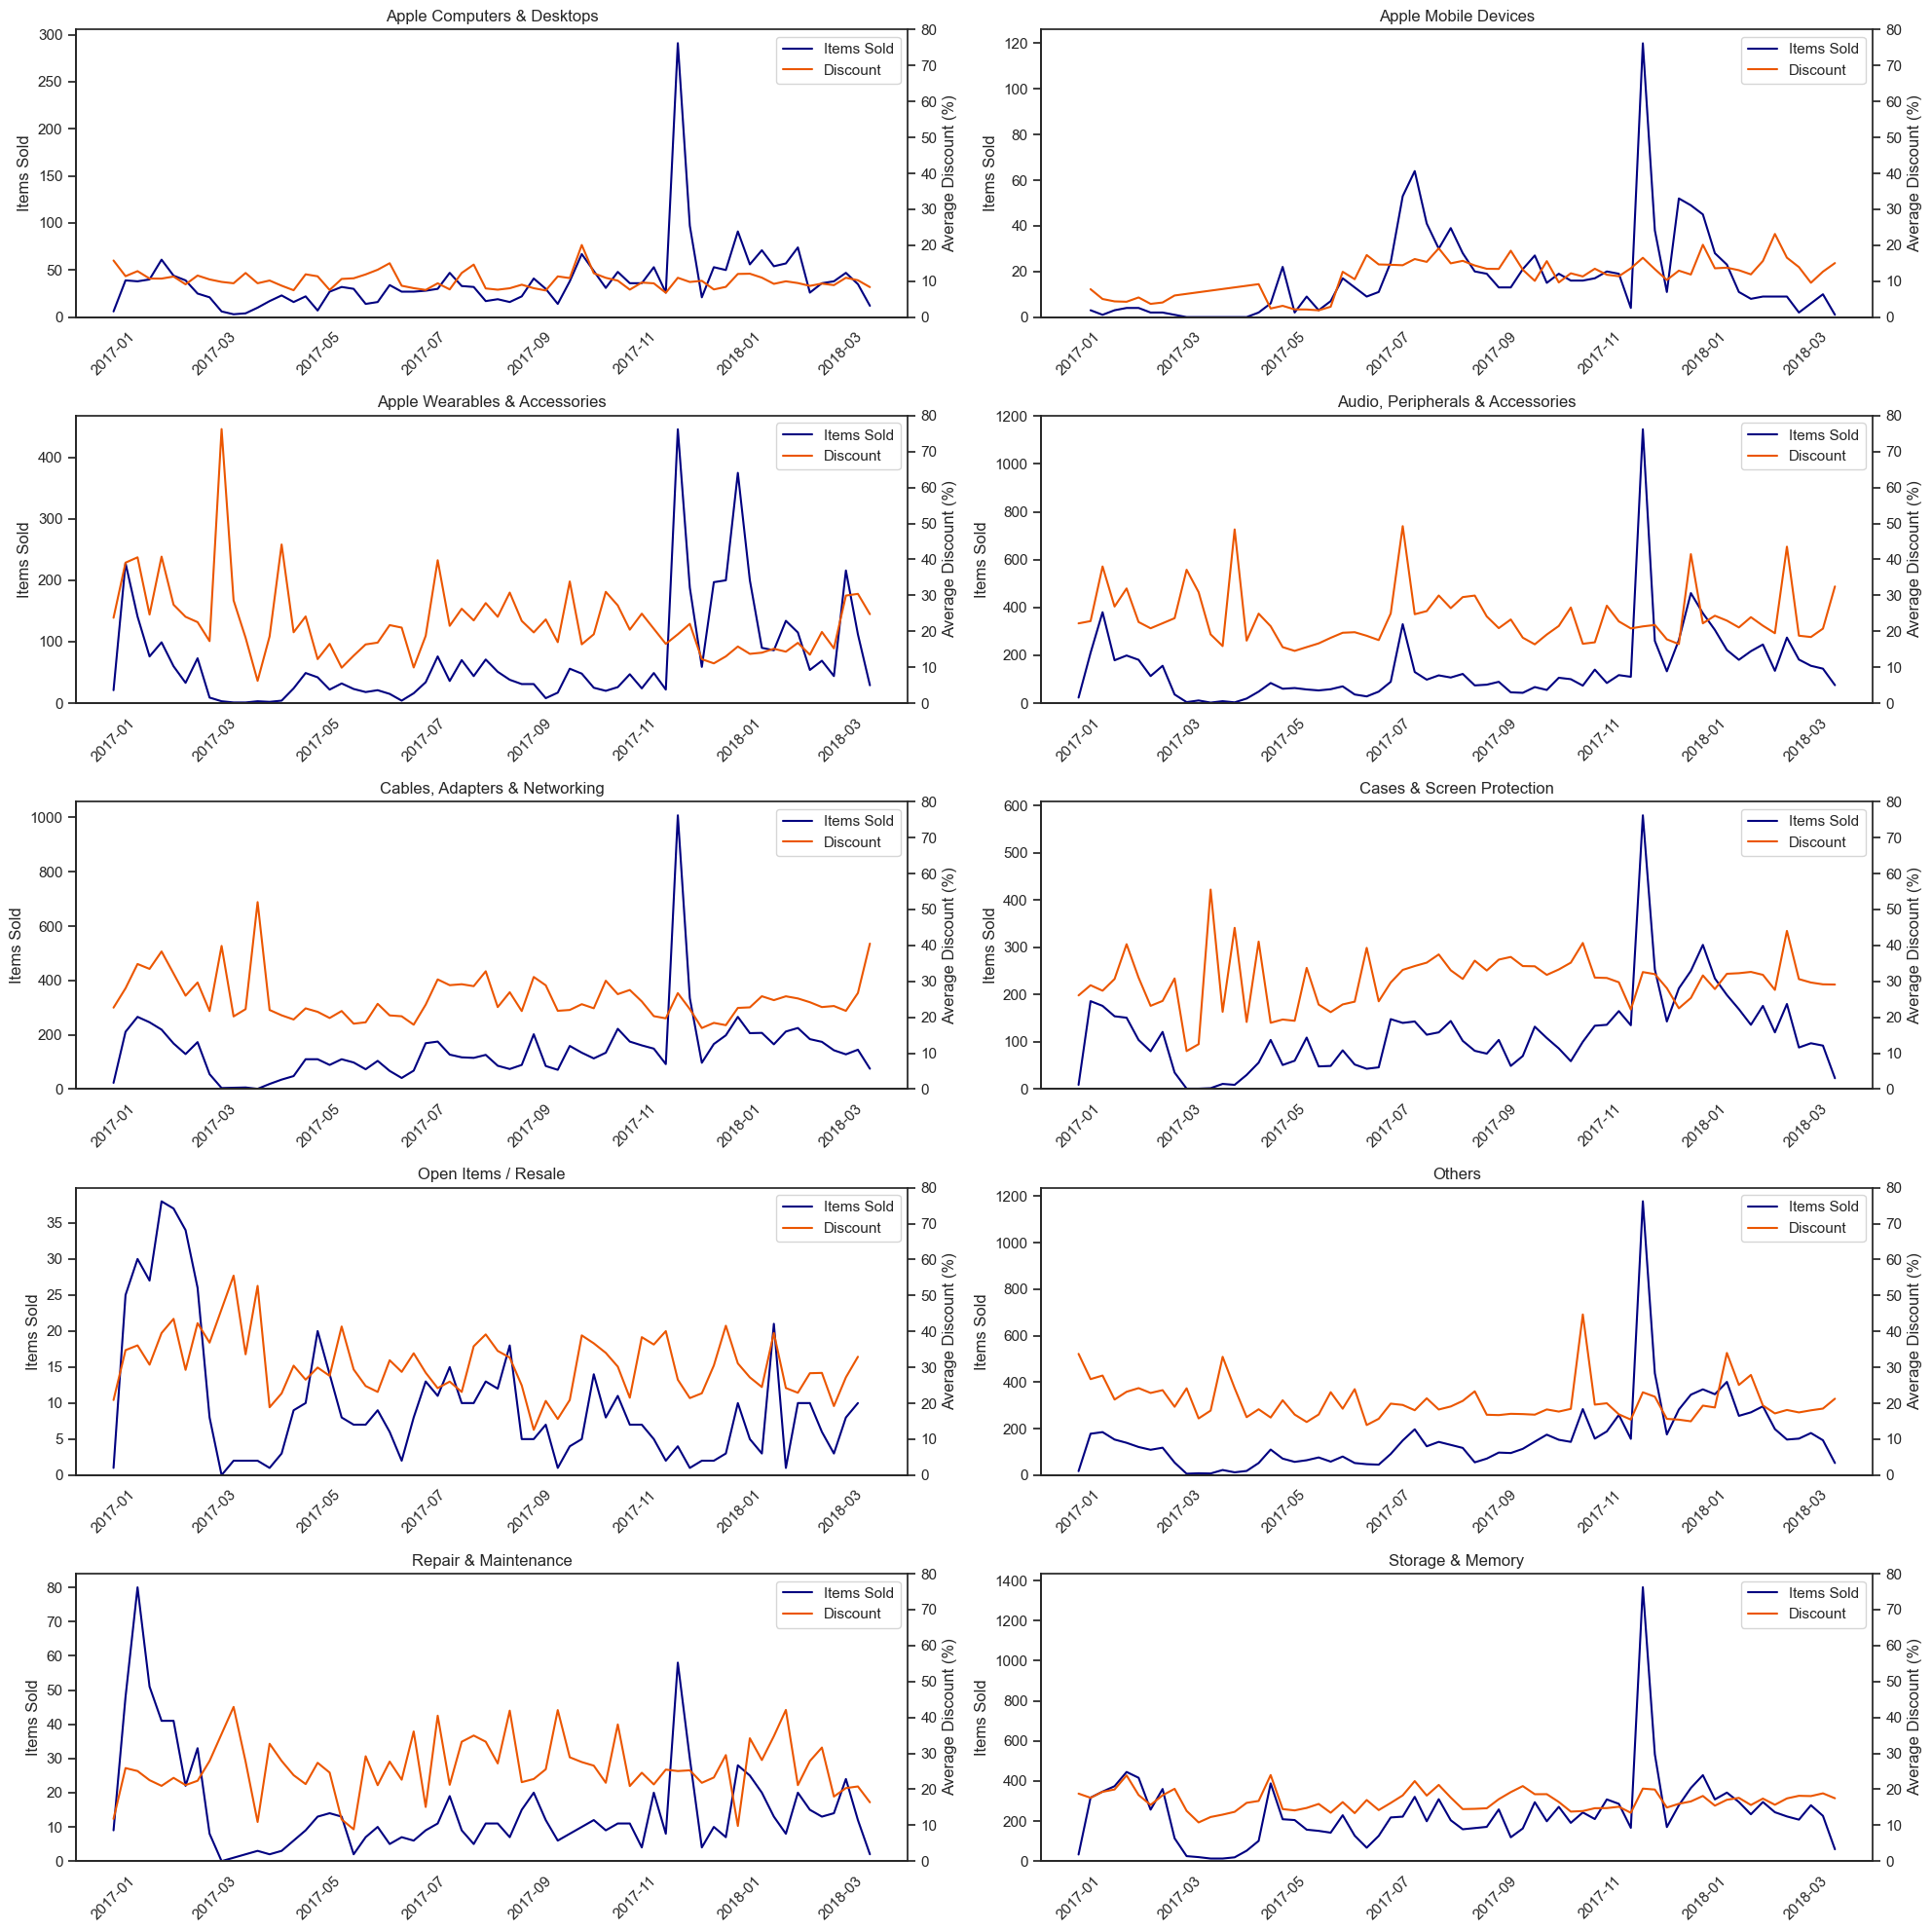

In [ ]:
# Plotting total sales x average discounts grouped by category
# 1. Initialize the FacetGrid (one subplot per category)
g = sns.FacetGrid(discount_week_cat_agg, col='category', col_wrap=2, height=4, aspect = 2.5, sharey=False)

# 2. Define the plotting function for the dual axis
def dual_axis_plot(data, **kwargs):
    ax = plt.gca()  # Get current axis

    # Plot Revenue (Primary Y-axis - Blue)
    sns.lineplot(data=data, x='date', y='product_quantity', ax=ax, color='navy', label='Items Sold')
    ax.set_xlabel("")
    ax.set_ylabel('Items Sold')
    ax.set_ylim(0, None)
    ax.tick_params(axis='x', labelrotation = 45)

    # Create the secondary axis
    ax2 = ax.twinx()

    # Plot Average Discount (Secondary Y-axis - Red)
    sns.lineplot(data=data, x='date', y='average_discount', ax=ax2, color='#EB5600', label='Discount')
    ax2.set_ylabel('Average Discount (%)')
    ax2.set_ylim(0, 80)

    # Optional: Combine legends so they don't overlap
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='best')

# 3. Map the function to the grid
g.map_dataframe(dual_axis_plot)

for ax in g.axes.flat:
    ax.tick_params(labelbottom=True)

# 4. Final Formatting
#g.set_axis_labels("Date", "")
g.set_titles("{col_name}")
plt.tight_layout()
plt.savefig("Weekly_sales_x_avg_discount_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

# Multi-Facet Visualization - Plotting average revenue per item sold x average discounts grouped by category

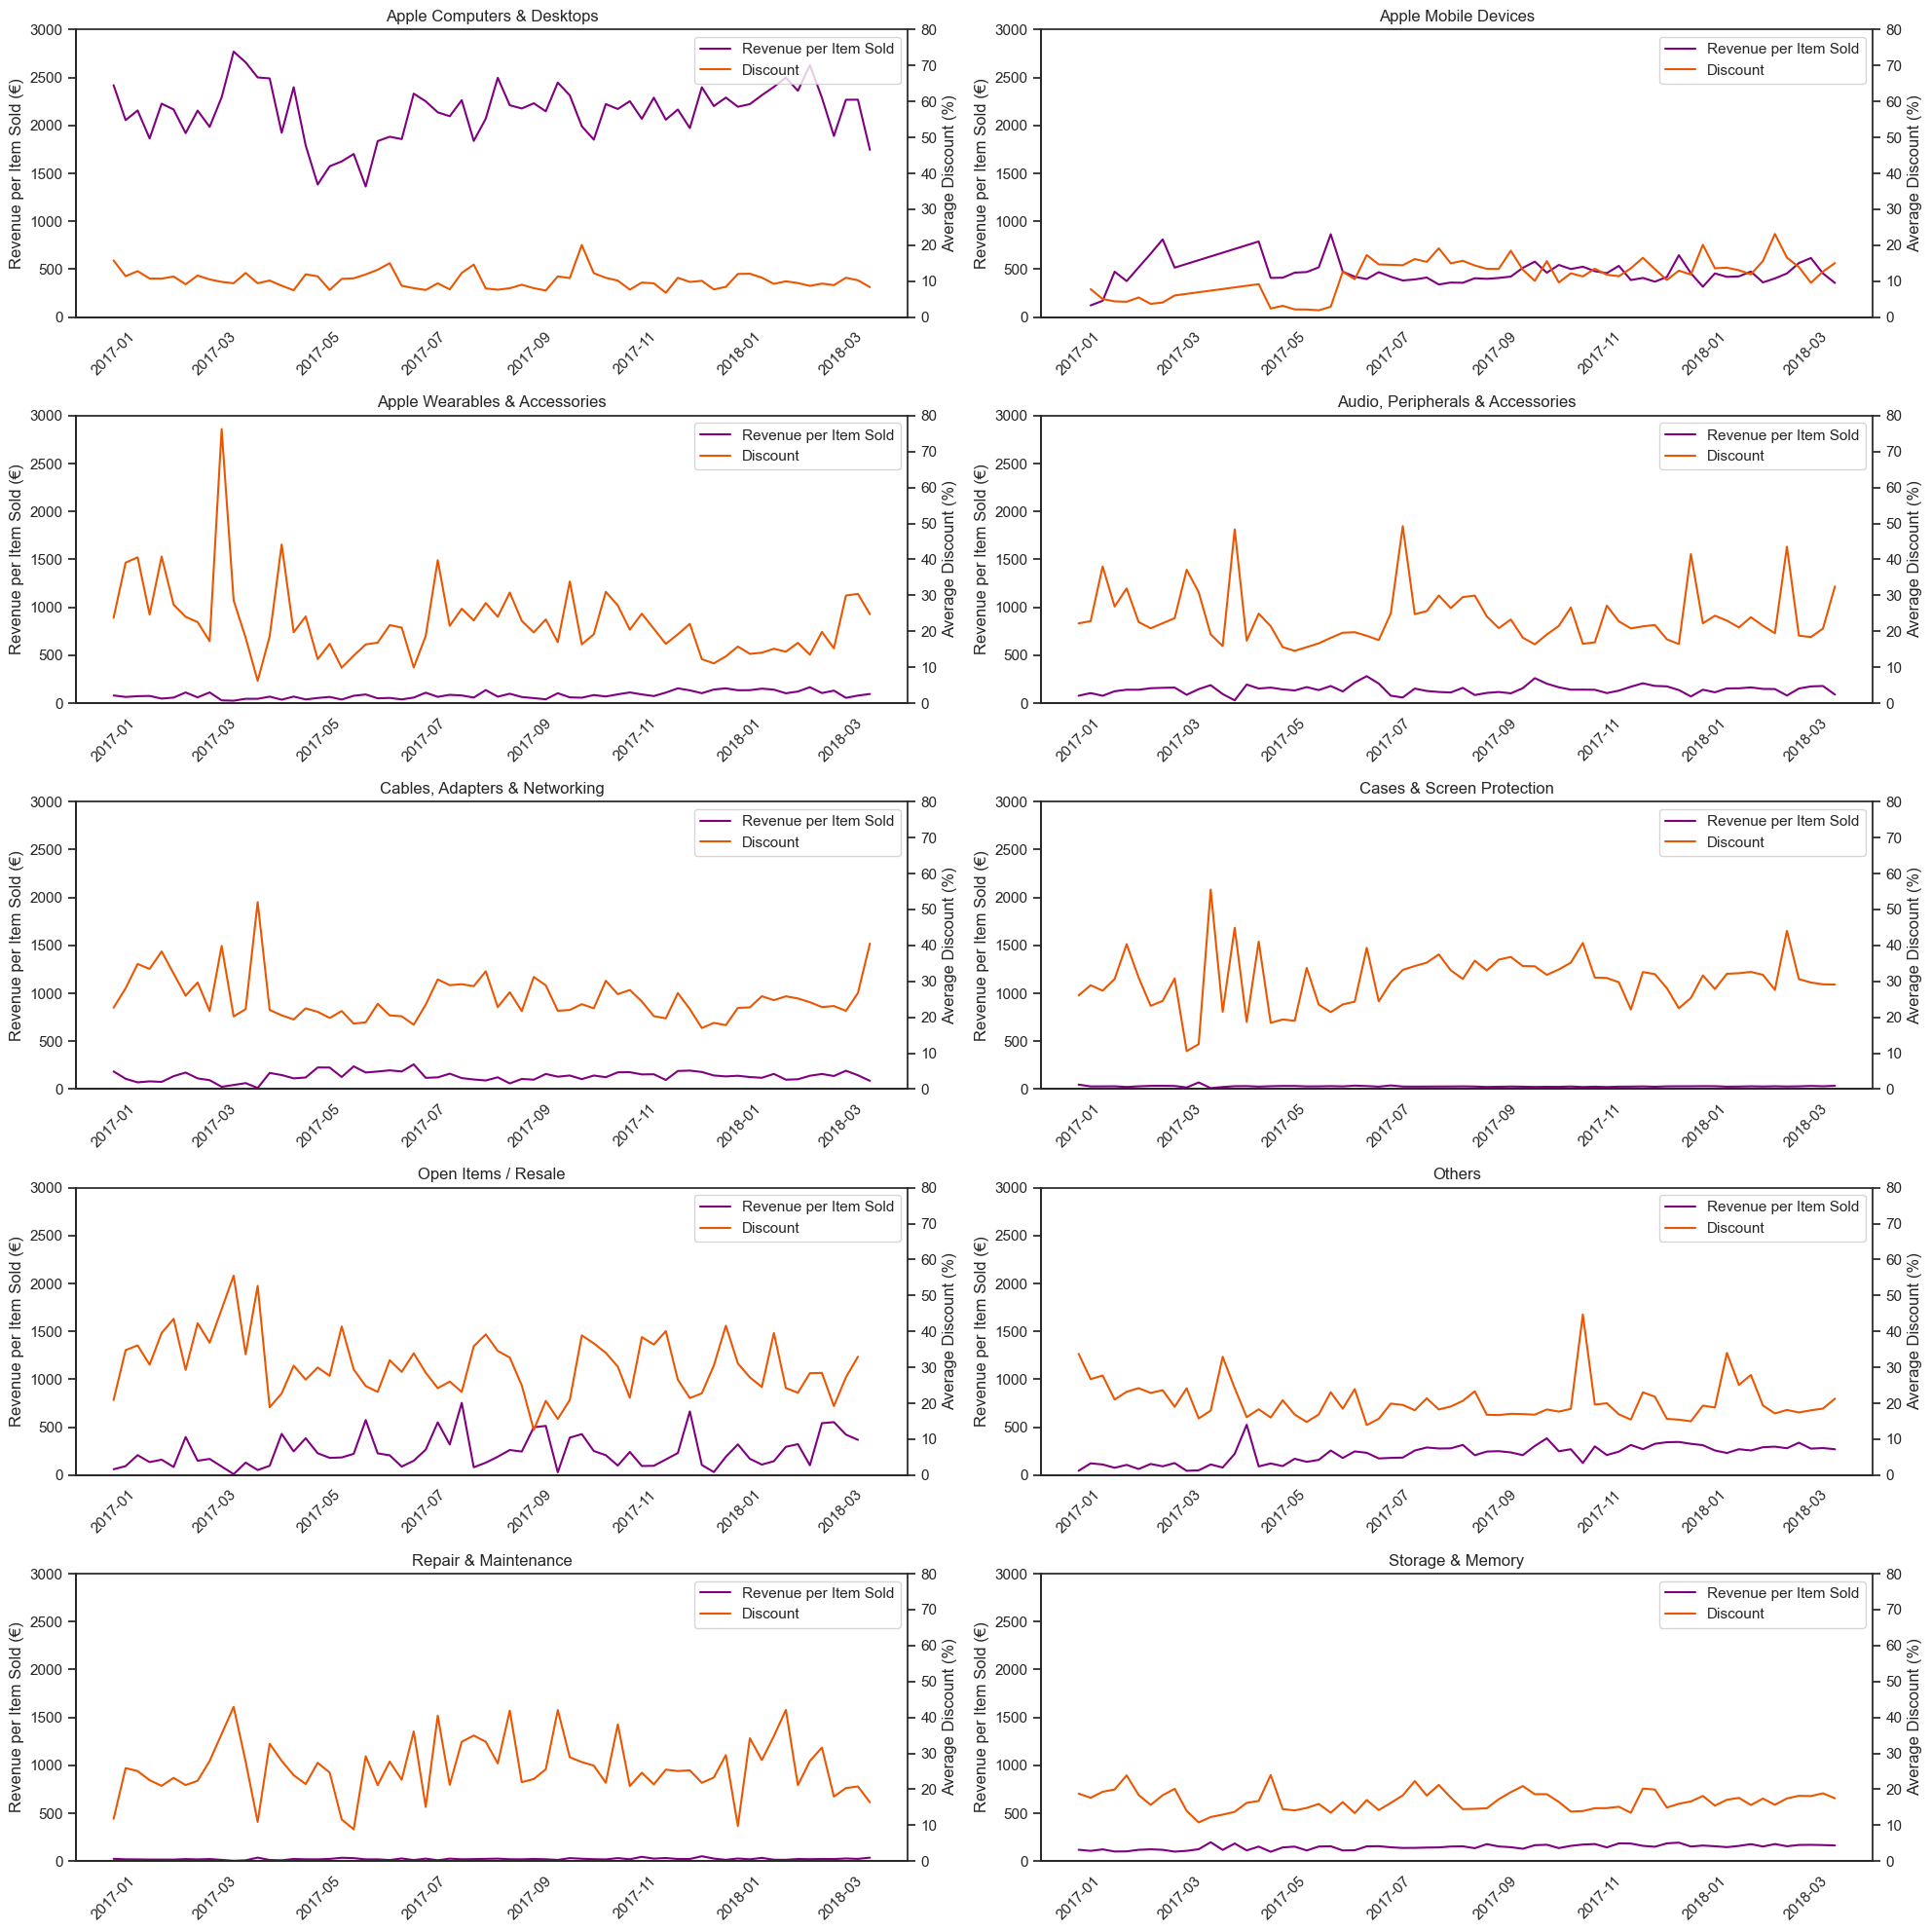

In [ ]:
# Plotting average revenue per item sold x average discounts grouped by category
# 1. Initialize the FacetGrid (one subplot per category)
g = sns.FacetGrid(discount_week_cat_agg, col='category', col_wrap=2, height=4, aspect = 2.5, sharey=False)

# 2. Define the plotting function for the dual axis
def dual_axis_plot(data, **kwargs):
    ax = plt.gca()  # Get current axis

    # Plot Revenue (Primary Y-axis - Blue)
    sns.lineplot(data=data, x='date', y='revenue_per_item', ax=ax, color='purple', label='Revenue per Item Sold')
    ax.set_xlabel("")
    ax.set_ylabel('Revenue per Item Sold (€)')
    ax.set_ylim(0, 3000)
    ax.tick_params(axis='x', labelrotation = 45)

    # Create the secondary axis
    ax2 = ax.twinx()

    # Plot Average Discount (Secondary Y-axis - Red)
    sns.lineplot(data=data, x='date', y='average_discount', ax=ax2, color='#EB5600', label='Discount')
    ax2.set_ylabel('Average Discount (%)')
    ax2.set_ylim(0, 80)

    # Optional: Combine legends so they don't overlap
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='best')

# 3. Map the function to the grid
g.map_dataframe(dual_axis_plot)

for ax in g.axes.flat:
    ax.tick_params(labelbottom=True)

# 4. Final Formatting
#g.set_axis_labels("Date", "")
g.set_titles("{col_name}")
plt.tight_layout()
plt.savefig("Weekly_rev_item_x_avg_discount.png", dpi=300, bbox_inches="tight")
plt.show()